# Variational Autoencoder on Real Galaxy Images  
## Galaxy10 DECaLS / Galaxy Zoo morphology dataset

This Colab notebook trains a **convolutional variational autoencoder (VAE)** on real galaxy images from the **Galaxy10 DECaLS** dataset.

Galaxy10 DECaLS contains real colour galaxy cutouts from the **DESI Legacy Imaging Surveys**, with morphology labels from **Galaxy Zoo**.  
The images have shape:

$$
N \times 256 \times 256 \times 3
$$

where the three channels correspond to optical colour-composite information based on $g,r,z$-band imaging.

The scientific goal is not only reconstruction, but also to learn a compact latent representation that may encode morphology, merger signatures, inclination, bars, spiral structure, compactness, and smoothness.

## 1. Scientific motivation

A galaxy image is a high-dimensional observable.  
For example, a $64\times64$ RGB cutout contains:

$$
64\times64\times3 = 12288
$$

pixel values.

A VAE compresses this image into a latent vector:

$$
z \in \mathbb{R}^{d_z}
$$

where $d_z$ may be 8, 16, 32, or 64.

Unlike a standard autoencoder, a VAE learns a **probabilistic latent representation**:

$$
q_\phi(z|x) =
\mathcal{N}\left(z;\mu_\phi(x), \mathrm{diag}(\sigma_\phi^2(x))\right)
$$

This is useful because it gives a continuous, regularized latent manifold rather than an arbitrary compressed representation.

## 2. VAE objective

The VAE maximizes the evidence lower bound:

$$
\log p_\theta(x)
\geq
\mathbb{E}_{q_\phi(z|x)}
\left[
\log p_\theta(x|z)
\right]
-
D_{\rm KL}
\left[
q_\phi(z|x)\,\|\,p(z)
\right]
$$

with prior:

$$
p(z)=\mathcal{N}(0,I)
$$

The loss minimized in the code is:

$$
\mathcal{L}
=
\mathcal{L}_{\rm rec}
+
\beta D_{\rm KL}
$$

where:

$$
\mathcal{L}_{\rm rec}
=
\sum_i (x_i-\hat{x}_i)^2
$$

and

$$
D_{\rm KL}
=
-\frac{1}{2}
\sum_j
\left[
1+\log\sigma_j^2-\mu_j^2-\sigma_j^2
\right].
$$

The parameter $\beta$ controls the strength of latent-space regularization.

## 3. Install packages

This notebook uses:

- `astroNN` to download/load Galaxy10 DECaLS,
- `PyTorch` for the VAE,
- `scikit-learn` for PCA/t-SNE latent-space visualization.

The first run will download the dataset.  
The Galaxy10 DECaLS file is large, so the first download may take some time in Colab.

```
mamba env create -f 9.yml
mamba activate galaxy
jupyter notebook 9.ipynb
```

## 4. Imports and device setup

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

import pkg_resources

from astroNN.datasets import load_galaxy10
from astroNN.datasets.galaxy10 import galaxy10cls_lookup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cpu


## 5. Load real galaxy images

Galaxy10 DECaLS classes:

0. Disturbed Galaxies  
1. Merging Galaxies  
2. Round Smooth Galaxies  
3. In-between Round Smooth Galaxies  
4. Cigar Shaped Smooth Galaxies  
5. Barred Spiral Galaxies  
6. Unbarred Tight Spiral Galaxies  
7. Unbarred Loose Spiral Galaxies  
8. Edge-on Galaxies without Bulge  
9. Edge-on Galaxies with Bulge

In [3]:
images, labels = load_galaxy10()

print("Raw image array:", images.shape, images.dtype)
print("Raw labels:", labels.shape, labels.dtype)

# Convert labels to int.
labels = labels.astype(np.int64)

# Show class names and counts.
unique, counts = np.unique(labels, return_counts=True)

print("\nClass distribution:")
for c, n in zip(unique, counts):
    print(f"{c}: {galaxy10cls_lookup(int(c)):<40s} {n}")

/home/fritz/.astroNN/datasets/Galaxy10_DECals.h5 was found!
Raw image array: (17736, 256, 256, 3) uint8
Raw labels: (17736,) uint8

Class distribution:
0: Disturbed                                1081
1: Merging                                  1853
2: Round Smooth                             2645
3: Smooth, Cigar shaped                     2027
4: Cigar Shaped Smooth                      334
5: Barred Spiral                            2043
6: Unbarred Tight Spiral                    1829
7: Unbarred Loose Spiral                    2628
8: Edge-on without Bulge                    1423
9: Edge-on with Bulge                       1873


## 6. Preprocessing

The original images are $256\times256$.  
For fast Colab training, we resize them to $64\times64$.

Pixel scaling:

$$
x \rightarrow \frac{x}{255}
$$

so that the network receives values in $[0,1]$.

The tensor layout is changed from:

$$
(N,H,W,C)
$$

to PyTorch format:

$$
(N,C,H,W).
$$

In [4]:
class Galaxy10TorchDataset(Dataset):
    def __init__(self, images, labels, image_size=64):
        self.images = images
        self.labels = labels
        self.image_size = image_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)

        # Robust conversion to [0,1].
        if img.max() > 1.5:
            img = img / 255.0

        img = np.clip(img, 0.0, 1.0)

        # NHWC image -> CHW tensor.
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        # Resize to selected training size.
        img = F.interpolate(
            img.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        label = int(self.labels[idx])
        return img, label


image_size = 64
batch_size = 96

full_dataset = Galaxy10TorchDataset(images, labels, image_size=image_size)

idx = np.arange(len(full_dataset))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels[temp_idx],
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 14188
Validation: 1774
Test: 1774


## 7. Visualize real galaxy examples

/home/fritz/.local/miniforge3/envs/galaxy/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


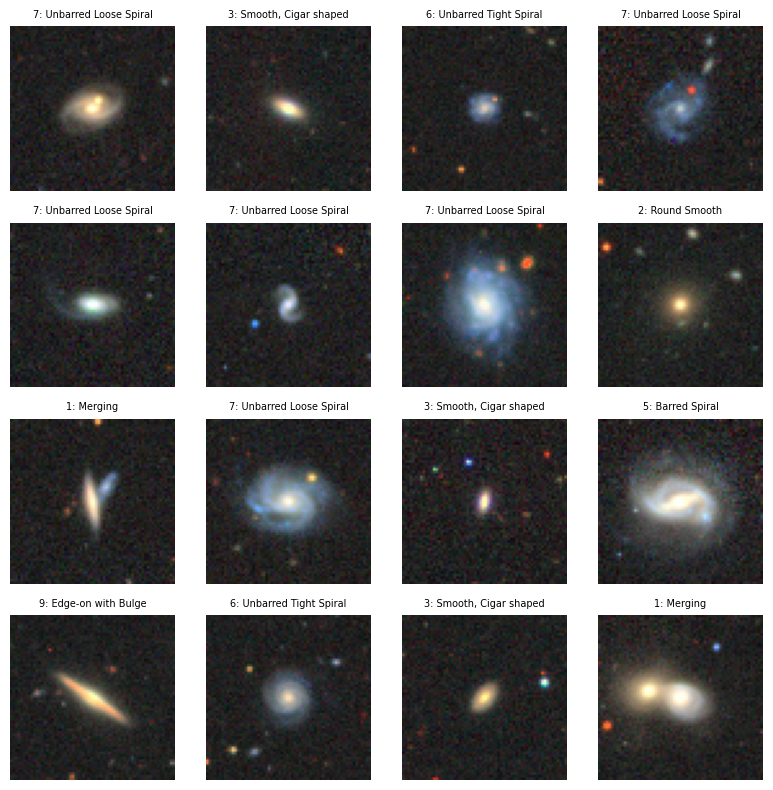

In [5]:
def show_galaxy_grid(loader, n=16):
    x, y = next(iter(loader))
    n = min(n, x.shape[0])

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    axes = axes.ravel()

    for i in range(n):
        img = x[i].permute(1, 2, 0).numpy()
        label = int(y[i])
        axes[i].imshow(img)
        axes[i].set_title(f"{label}: {galaxy10cls_lookup(label)}", fontsize=7)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_galaxy_grid(train_loader, n=16)

## 8. Convolutional VAE model

Encoder:

$$
x \rightarrow \mu_\phi(x),\log\sigma_\phi^2(x)
$$

Reparameterization:

$$
z = \mu + \sigma\epsilon,\quad \epsilon\sim\mathcal{N}(0,I)
$$

Decoder:

$$
z \rightarrow \hat{x}
$$

The decoder ends with a sigmoid activation because the images are scaled to $[0,1]$.

In [6]:
class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=32, image_size=64):
        super().__init__()
        self.in_channels = in_channels
        self.latent_dim = latent_dim
        self.image_size = image_size

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),   # 64 -> 32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),            # 32 -> 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),           # 16 -> 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),          # 8 -> 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.feature_shape = (256, image_size // 16, image_size // 16)
        feature_dim = int(np.prod(self.feature_shape))

        self.fc_mu = nn.Linear(feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(feature_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, feature_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 4 -> 8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16 -> 32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1), # 32 -> 64
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.reshape(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.reshape(z.size(0), *self.feature_shape)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


latent_dim = 32
model = ConvVAE(in_channels=3, latent_dim=latent_dim, image_size=image_size).to(device)

print(model)

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_mu): Linear(in_features=4096, out_features=32, bias=True)
  (fc_logvar): Linear(in

## 9. Loss function

For display-scaled galaxy images, MSE is a stable starting point:

$$
\mathcal{L}_{\rm rec}
=
\frac{1}{B}
\sum_{b=1}^{B}
\sum_i
(x_{b,i}-\hat{x}_{b,i})^2
$$

The KL term regularizes the latent distribution:

$$
D_{\rm KL}
=
-\frac{1}{2}
\sum_j
(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2).
$$

For real calibrated flux images, a better loss would use inverse-variance weighting:

$$
\mathcal{L}_{\rm rec}
=
\sum_i
\frac{(x_i-\hat{x}_i)^2}{\sigma_i^2}.
$$

In [7]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    rec = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = rec + beta * kl
    return total, rec, kl

## 10. Train the VAE

For a quick Colab run, start with 15 epochs.  
For better galaxy reconstructions, use 30–100 epochs.

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

num_epochs = 15
beta = 0.3

history = {
    "train_total": [],
    "train_rec": [],
    "train_kl": [],
    "val_total": [],
    "val_rec": [],
    "val_kl": [],
}

def run_epoch(loader, train=True):
    model.train(train)

    total_loss = 0.0
    total_rec = 0.0
    total_kl = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            x_hat, mu, logvar, z = model(x)
            loss, rec, kl = vae_loss(x, x_hat, mu, logvar, beta=beta)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item()
        total_rec += rec.item()
        total_kl += kl.item()
        n_batches += 1

    return total_loss / n_batches, total_rec / n_batches, total_kl / n_batches


for epoch in range(1, num_epochs + 1):
    train_total, train_rec, train_kl = run_epoch(train_loader, train=True)
    val_total, val_rec, val_kl = run_epoch(val_loader, train=False)

    history["train_total"].append(train_total)
    history["train_rec"].append(train_rec)
    history["train_kl"].append(train_kl)
    history["val_total"].append(val_total)
    history["val_rec"].append(val_rec)
    history["val_kl"].append(val_kl)

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_total:.3f} rec={train_rec:.3f} kl={train_kl:.3f} | "
        f"val={val_total:.3f} rec={val_rec:.3f} kl={val_kl:.3f}"
    )

/home/fritz/.local/miniforge3/envs/galaxy/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


Epoch 001 | train=188.206 rec=182.627 kl=18.594 | val=64.586 rec=58.888 kl=18.995
Epoch 002 | train=53.853 rec=48.696 kl=17.190 | val=53.402 rec=47.795 kl=18.692
Epoch 003 | train=51.305 rec=45.782 kl=18.409 | val=50.390 rec=44.460 kl=19.766
Epoch 004 | train=49.687 rec=43.879 kl=19.358 | val=50.255 rec=44.698 kl=18.524
Epoch 005 | train=48.759 rec=42.778 kl=19.937 | val=49.797 rec=43.272 kl=21.750
Epoch 006 | train=48.309 rec=42.236 kl=20.243 | val=48.719 rec=42.815 kl=19.682
Epoch 007 | train=47.900 rec=41.744 kl=20.521 | val=47.911 rec=42.007 kl=19.679
Epoch 008 | train=47.461 rec=41.306 kl=20.515 | val=47.995 rec=41.730 kl=20.884
Epoch 009 | train=47.175 rec=40.963 kl=20.707 | val=48.138 rec=41.719 kl=21.397
Epoch 010 | train=46.804 rec=40.574 kl=20.765 | val=47.057 rec=40.731 kl=21.088
Epoch 011 | train=46.750 rec=40.472 kl=20.927 | val=47.412 rec=41.127 kl=20.950
Epoch 012 | train=46.547 rec=40.237 kl=21.034 | val=47.244 rec=41.142 kl=20.341
Epoch 013 | train=46.329 rec=40.000 kl

## 11. Training curves

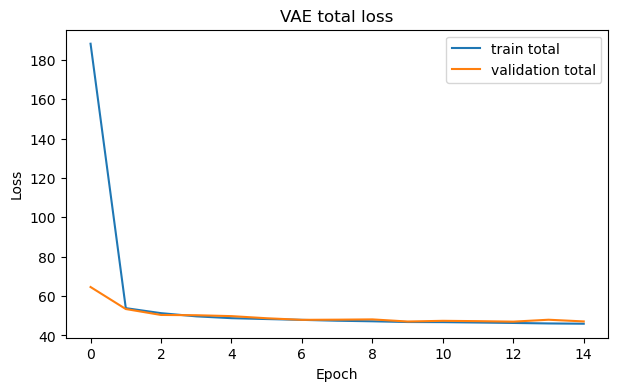

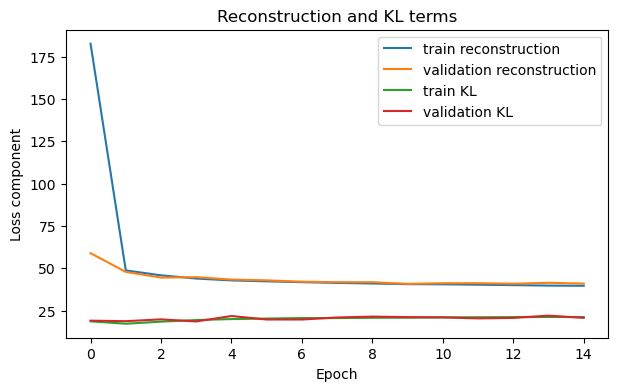

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_total"], label="train total")
plt.plot(history["val_total"], label="validation total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE total loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["train_rec"], label="train reconstruction")
plt.plot(history["val_rec"], label="validation reconstruction")
plt.plot(history["train_kl"], label="train KL")
plt.plot(history["val_kl"], label="validation KL")
plt.xlabel("Epoch")
plt.ylabel("Loss component")
plt.legend()
plt.title("Reconstruction and KL terms")
plt.show()

## 12. Reconstructions and residuals

The residual image:

$$
R = |x-\hat{x}|
$$

can highlight morphology not captured by the VAE: spiral arms, bars, mergers, tidal structures, compact nuclei, or image artefacts.

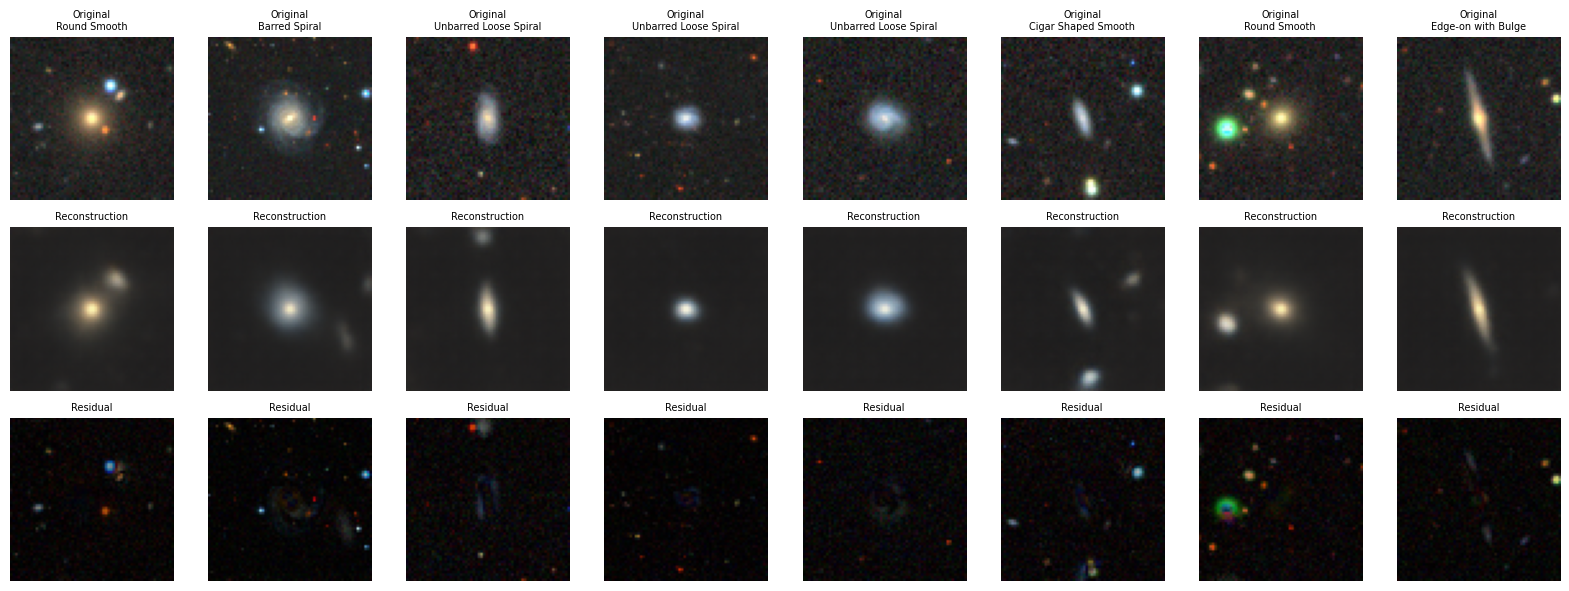

In [10]:
model.eval()

x, y = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    x_hat, mu, logvar, z = model(x)

x_cpu = x.cpu()
xhat_cpu = x_hat.cpu()
res_cpu = torch.abs(x_cpu - xhat_cpu)

n = 8

fig, axes = plt.subplots(3, n, figsize=(2*n, 6))

for i in range(n):
    label = int(y[i])

    axes[0, i].imshow(x_cpu[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"Original\n{galaxy10cls_lookup(label)}", fontsize=7)
    axes[0, i].axis("off")

    axes[1, i].imshow(xhat_cpu[i].permute(1, 2, 0).numpy())
    axes[1, i].set_title("Reconstruction", fontsize=7)
    axes[1, i].axis("off")

    axes[2, i].imshow(res_cpu[i].permute(1, 2, 0).numpy())
    axes[2, i].set_title("Residual", fontsize=7)
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## 13. Extract latent representations

We use the encoder mean:

$$
\mu_\phi(x)
$$

as the deterministic latent embedding of each galaxy.

In [11]:
def extract_latents(loader):
    model.eval()
    all_mu = []
    all_logvar = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            mu, logvar = model.encode(x)
            all_mu.append(mu.cpu().numpy())
            all_logvar.append(logvar.cpu().numpy())
            all_labels.append(y.numpy())

    return (
        np.concatenate(all_mu, axis=0),
        np.concatenate(all_logvar, axis=0),
        np.concatenate(all_labels, axis=0),
    )

latent_mu, latent_logvar, latent_labels = extract_latents(test_loader)

print("Latent means:", latent_mu.shape)
print("Latent labels:", latent_labels.shape)

Latent means: (1774, 32)
Latent labels: (1774,)


## 14. PCA projection of galaxy latent space

This plot asks whether an unsupervised VAE representation separates broad morphology classes.

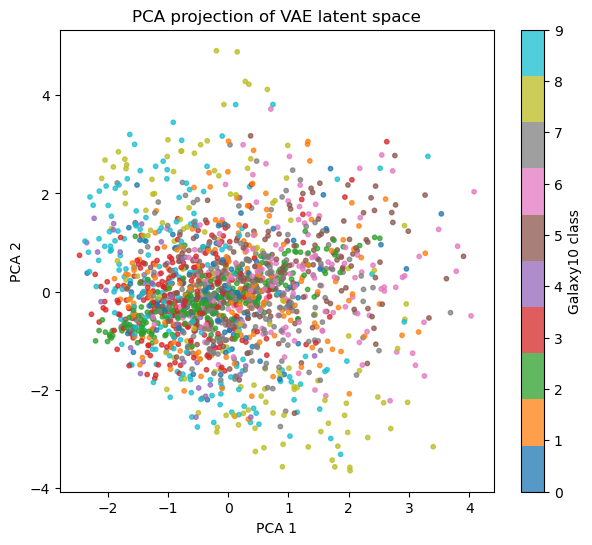

Explained variance ratio: [0.06882784 0.06738959]


In [12]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_mu)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    latent_pca[:, 0],
    latent_pca[:, 1],
    c=latent_labels,
    s=10,
    alpha=0.75,
    cmap="tab10"
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA projection of VAE latent space")
cbar = plt.colorbar(sc)
cbar.set_label("Galaxy10 class")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## 15. t-SNE projection

t-SNE is useful for visual inspection of latent neighborhoods.  
For real science, UMAP or density-based clustering may be more scalable.

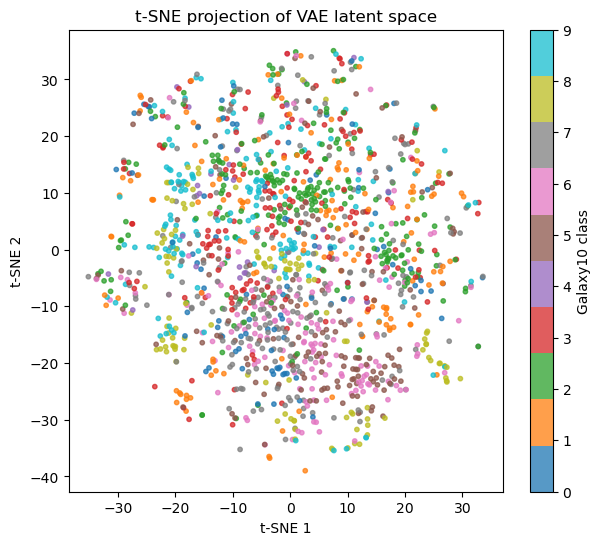

In [13]:
subset = min(1500, latent_mu.shape[0])
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    random_state=42
)

latent_tsne = tsne.fit_transform(latent_mu[:subset])

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    latent_tsne[:, 0],
    latent_tsne[:, 1],
    c=latent_labels[:subset],
    s=10,
    alpha=0.75,
    cmap="tab10"
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection of VAE latent space")
cbar = plt.colorbar(sc)
cbar.set_label("Galaxy10 class")
plt.show()

## 16. Nearest-neighbour inspection in latent space

This is scientifically important:  
latent-space proximity should correspond to visual or morphological similarity.

We choose one test galaxy and show its nearest neighbours in the VAE latent space.

/home/fritz/.local/miniforge3/envs/galaxy/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


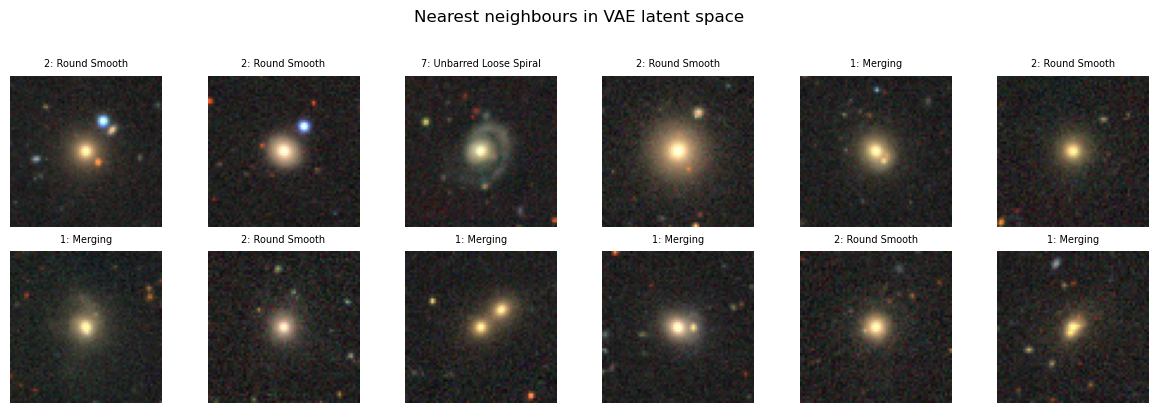

In [14]:
def get_all_test_images(loader):
    xs = []
    ys = []
    for x, y in loader:
        xs.append(x)
        ys.append(y)
    return torch.cat(xs, dim=0), torch.cat(ys, dim=0)

test_images_tensor, test_labels_tensor = get_all_test_images(test_loader)

query_index = 0

dist = np.linalg.norm(latent_mu - latent_mu[query_index], axis=1)
nearest = np.argsort(dist)[:12]

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
axes = axes.ravel()

for ax, idx_nn in zip(axes, nearest):
    img = test_images_tensor[idx_nn].permute(1, 2, 0).numpy()
    lab = int(test_labels_tensor[idx_nn])
    ax.imshow(img)
    ax.set_title(f"{lab}: {galaxy10cls_lookup(lab)}", fontsize=7)
    ax.axis("off")

plt.suptitle("Nearest neighbours in VAE latent space", y=1.02)
plt.tight_layout()
plt.show()

## 17. Reconstruction-based anomaly score

A simple VAE anomaly score is:

$$
A(x)
=
\frac{1}{N_{\rm pix}}
\sum_i
(x_i-\hat{x}_i)^2
$$

High-score objects may be:

- mergers,
- disturbed galaxies,
- rare morphologies,
- image artefacts,
- objects poorly represented by the training distribution.

In [15]:
def reconstruction_scores(loader):
    model.eval()
    scores = []
    labels_out = []
    imgs = []
    recs = []

    with torch.no_grad():
        for x, y in loader:
            x_dev = x.to(device)
            x_hat, mu, logvar, z = model(x_dev)
            mse = ((x_dev - x_hat) ** 2).mean(dim=(1, 2, 3))

            scores.append(mse.cpu().numpy())
            labels_out.append(y.numpy())
            imgs.append(x.cpu())
            recs.append(x_hat.cpu())

    return (
        np.concatenate(scores),
        np.concatenate(labels_out),
        torch.cat(imgs, dim=0),
        torch.cat(recs, dim=0),
    )

scores, score_labels, score_imgs, score_recs = reconstruction_scores(test_loader)

print("Reconstruction anomaly-score percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p:2d}th percentile: {np.percentile(scores, p):.6f}")

Reconstruction anomaly-score percentiles:
50th percentile: 0.003086
75th percentile: 0.003827
90th percentile: 0.004631
95th percentile: 0.005288
99th percentile: 0.006432


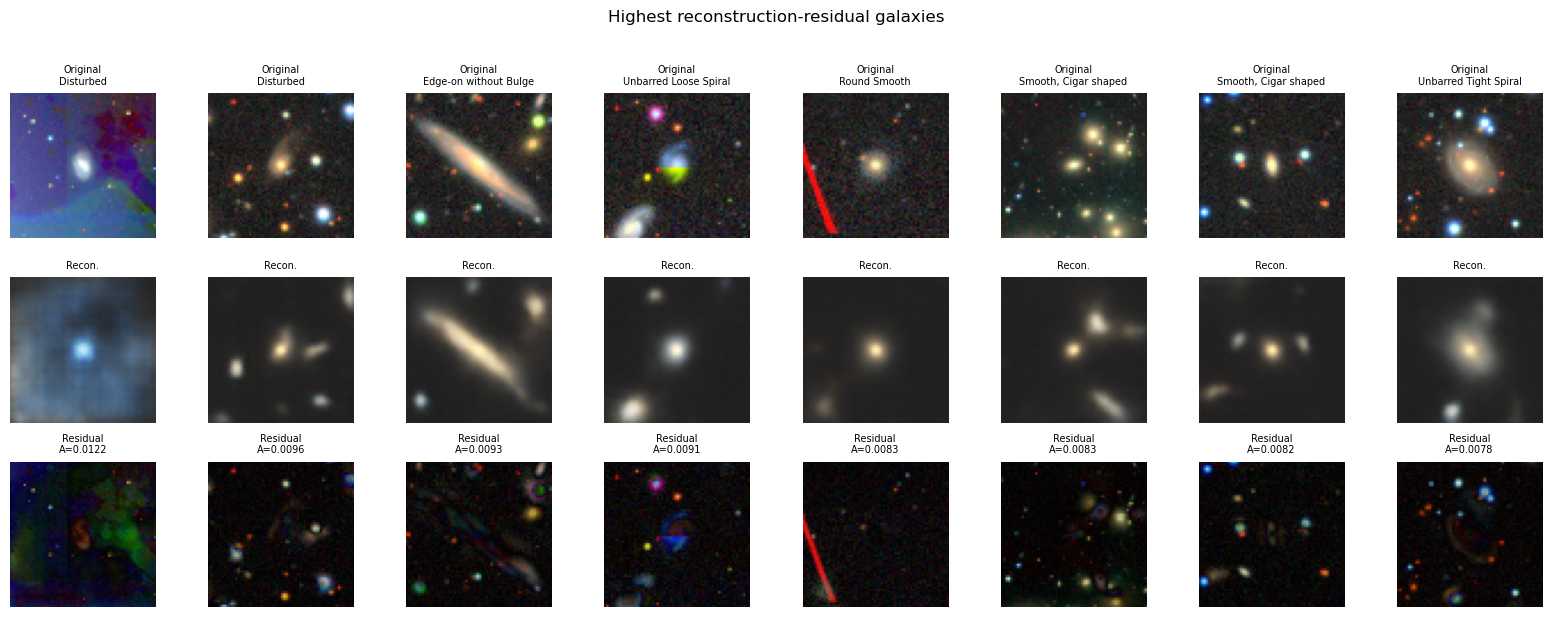

In [16]:
top_idx = np.argsort(scores)[-8:][::-1]

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for j, idx_top in enumerate(top_idx):
    img = score_imgs[idx_top]
    rec = score_recs[idx_top]
    res = torch.abs(img - rec)
    lab = int(score_labels[idx_top])

    axes[0, j].imshow(img.permute(1, 2, 0).numpy())
    axes[0, j].set_title(f"Original\n{galaxy10cls_lookup(lab)}", fontsize=7)
    axes[0, j].axis("off")

    axes[1, j].imshow(rec.permute(1, 2, 0).numpy())
    axes[1, j].set_title("Recon.", fontsize=7)
    axes[1, j].axis("off")

    axes[2, j].imshow(res.permute(1, 2, 0).numpy())
    axes[2, j].set_title(f"Residual\nA={scores[idx_top]:.4f}", fontsize=7)
    axes[2, j].axis("off")

plt.suptitle("Highest reconstruction-residual galaxies", y=1.02)
plt.tight_layout()
plt.show()

## 18. Generate new galaxy-like samples

Sampling from the prior:

$$
z\sim\mathcal{N}(0,I)
$$

produces examples from the learned decoder distribution.

For science use, treat generated images as diagnostic only unless the generative model is carefully validated.

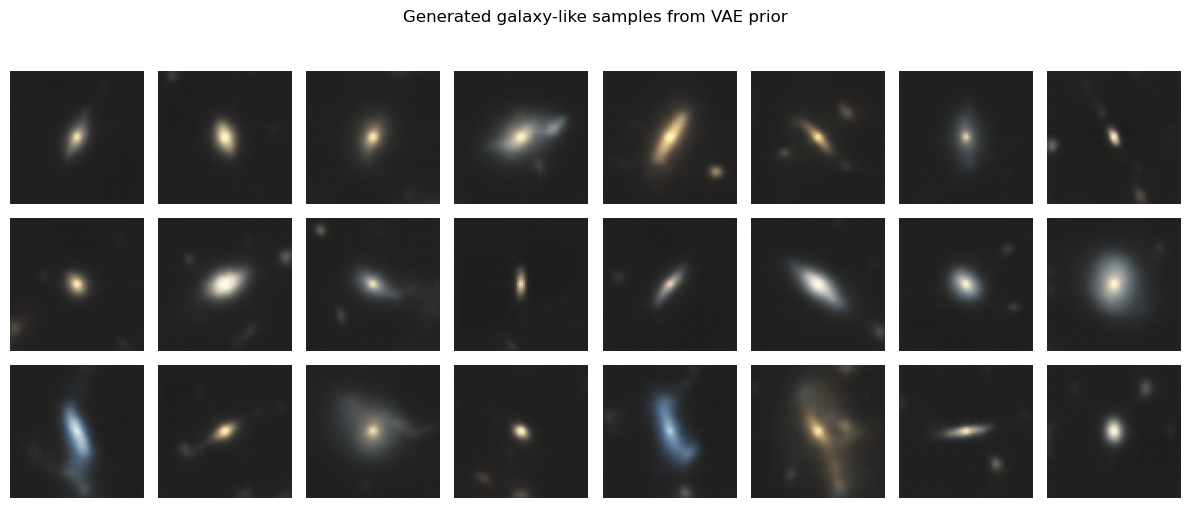

In [17]:
model.eval()

with torch.no_grad():
    z = torch.randn(24, latent_dim).to(device)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(samples[i].permute(1, 2, 0).numpy())
    ax.axis("off")

plt.suptitle("Generated galaxy-like samples from VAE prior", y=1.02)
plt.tight_layout()
plt.show()

## 19. Save model and latent table

The saved latent table can be used for:

- clustering,
- cross-match with physical parameters,
- morphology comparison,
- anomaly ranking,
- downstream supervised classification.

In [ ]:
save_dir = "./galaxy10_vae_outputs"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_dir, "conv_vae_galaxy10_decals.pt"))

np.save(os.path.join(save_dir, "latent_mu_test.npy"), latent_mu)
np.save(os.path.join(save_dir, "latent_logvar_test.npy"), latent_logvar)
np.save(os.path.join(save_dir, "labels_test.npy"), latent_labels)
np.save(os.path.join(save_dir, "reconstruction_scores_test.npy"), scores)

print("Saved outputs to:", save_dir)

## 20. Next scientific upgrades

### A. Larger image size

Use:

```python
image_size = 128
```

or keep $256\times256$ if GPU memory allows.

### B. Stronger decoder

Galaxy images contain fine structures.  
A standard VAE often over-smooths spiral arms and tidal features.  
Useful upgrades:

- residual blocks,
- U-Net-like skip connections,
- perceptual loss,
- hierarchical VAE,
- VQ-VAE,
- diffusion autoencoder.

### C. Conditional VAE

Condition on morphology class, redshift, or colour:

$$
p_\theta(x|z,c)
$$

where $c$ may be a class label or physical metadata.

### D. Astronomical weighted likelihood

If calibrated images and variance maps are available:

$$
\mathcal{L}_{\rm rec}
=
\sum_i
\frac{(x_i-\hat{x}_i)^2}{\sigma_i^2}
$$

This is preferable to unweighted MSE.

### E. Domain adaptation

For LSST, Euclid, Roman, HSC, or SDSS transfer, account for:

- PSF differences,
- survey depth,
- seeing,
- pixel scale,
- passband differences,
- redshift distribution,
- surface-brightness selection.

# End

This notebook trains a VAE directly on real Galaxy10 DECaLS galaxy images and produces:

1. reconstructions,  
2. residual maps,  
3. latent-space PCA/t-SNE projections,  
4. nearest-neighbour morphology inspection,  
5. reconstruction-based anomaly scores,  
6. generated galaxy-like samples.